In [1]:
# /// script
# requires-python = ">=3.10"
# dependencies = [
#     "matplotlib",
#     "numpy",
#     "scikit-image",
#     "scipy",
#     "tifffile",
#     "imagecodecs",
#     "pandas",
#     "seaborn",
#     "bobiac_tools @ git+https://github.com/bobiac/bobiac-tools.git"
# ]
# ///

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import skimage
import tifffile
from bobiac_tools import overlay_labels
from scipy.spatial import KDTree

In [3]:
path_image = "../../../_static/images/quant/05_spatial_stats/images/F01_202.tif"
path_mask = "../../../_static/images/quant/05_spatial_stats/masks/F01_202w1.TIF"
path_spots = "../../../_static/images/quant/05_spatial_stats/spots/F01_202_spots.csv"

image = tifffile.imread(path_image)
mask = tifffile.imread(path_mask)
df_spots = pd.read_csv(path_spots)

mask = skimage.segmentation.clear_border(mask)

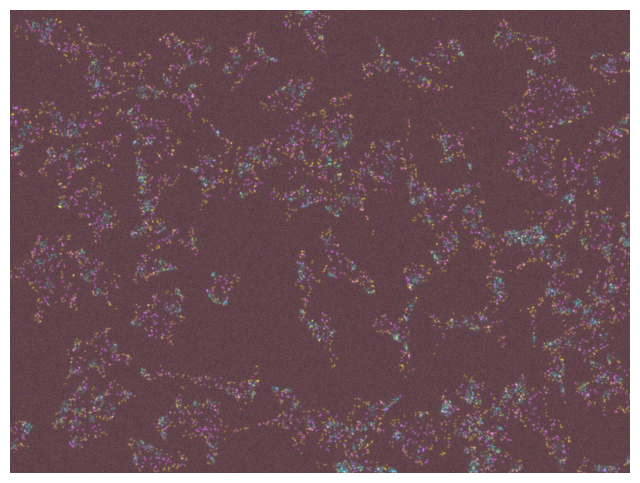

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [4]:
overlay_labels(image[2:, :, :])

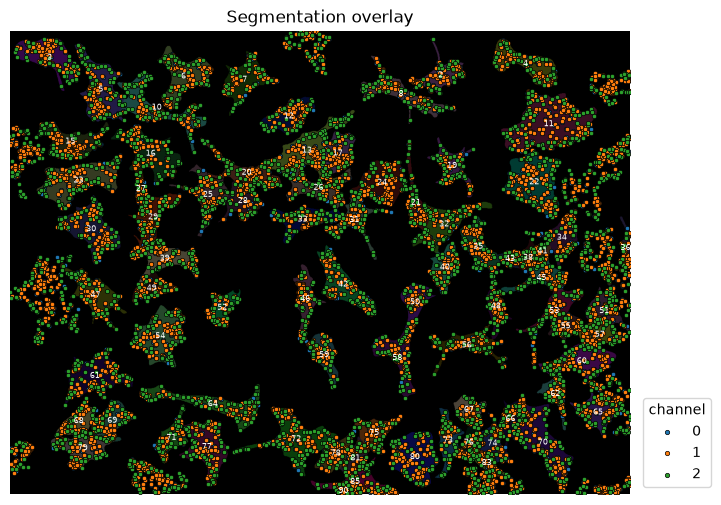

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

In [5]:
overlay_labels(label_mask=mask, coordinates=df_spots)

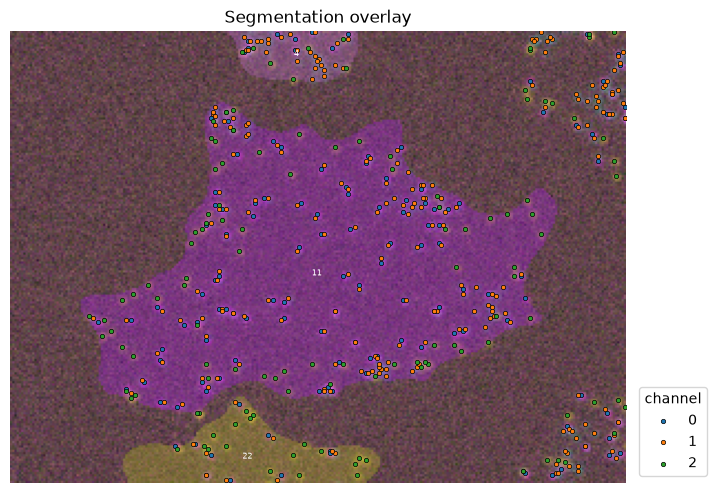

(<Figure size 800x587.05 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

In [6]:
overlay_labels(
    image=image[2:, :, :], label_mask=mask, coordinates=df_spots, focus_object=11
)

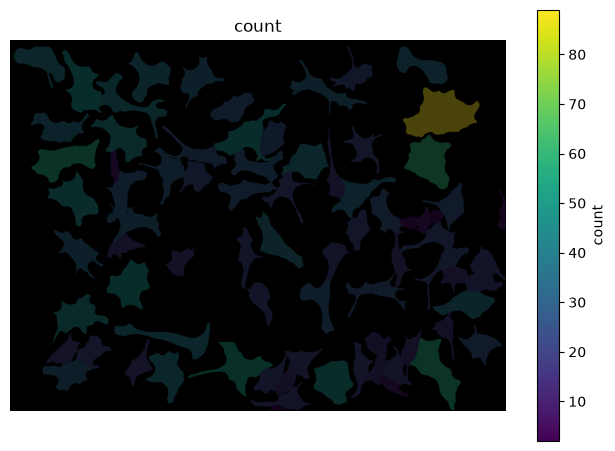

(<Figure size 800x800 with 2 Axes>, <Axes: title={'center': 'count'}>)

In [7]:
df_cell = pd.DataFrame(
    skimage.measure.regionprops_table(mask, properties=["area", "label"])
)

# map the cell label to the spots
df_spots["label_cell"] = mask[df_spots["y"].astype(int), df_spots["x"].astype(int)]
# delete spots in the background
df_spots = df_spots.loc[df_spots["label_cell"] != 0]
# count number of spots per cell label
mapping_spots = (
    df_spots.loc[df_spots["channel"] == 0]["label_cell"].value_counts().reset_index()
)
# add the cell count to the cell dataframe
df_cell = df_cell.merge(
    mapping_spots, left_on="label", right_on="label_cell", how="inner"
).drop(columns="label_cell")
overlay_labels(label_mask=mask, df=df_cell, id_col="label", measurement_col="count")

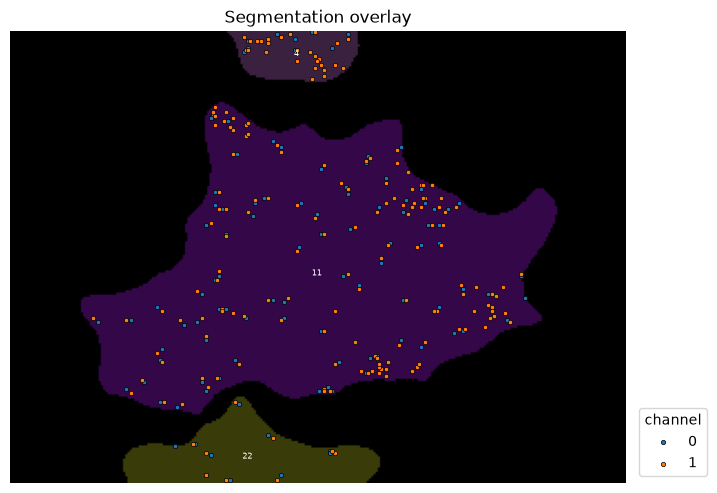

(<Figure size 800x587.05 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

In [8]:
cell_id = 11
overlay_labels(
    label_mask=mask,
    coordinates=df_spots.loc[df_spots["channel"].isin([0, 1])],
    focus_object=cell_id,
)

In [9]:
# or use:
# from bobiac_tools import random_points_in_mask


def random_points_in_mask(mask: np.ndarray, cell_label: int, n: int) -> np.ndarray:
    """
    Generate n random points uniformly distributed within a labeled cell region.

    Points are placed continuously using rejection sampling:
    candidate points are drawn uniformly from the bounding box of the cell and
    accepted only if they fall within the cell mask. This correctly handles
    irregular cell shapes and serves as a null model for Complete Spatial
    Randomness (CSR).

    Parameters
    ----------
    mask : 2D numpy array
        Label mask where each cell is identified by a unique integer ID
        and background is 0.
    cell_label : int
        ID of the cell to sample within.
    n : int
        Number of random points to generate.

    Returns
    -------
    points : (n, 2) numpy array
        Random point coordinates in (row, col) / (y, x) order.
    """
    ys, xs = np.where(mask == cell_label)
    y_min, y_max = ys.min(), ys.max()
    x_min, x_max = xs.min(), xs.max()
    points = []
    while len(points) < n:
        y = np.random.uniform(y_min, y_max)
        x = np.random.uniform(x_min, x_max)
        if mask[int(round(y)), int(round(x))] == cell_label:
            points.append([y, x])
    return np.array(points)

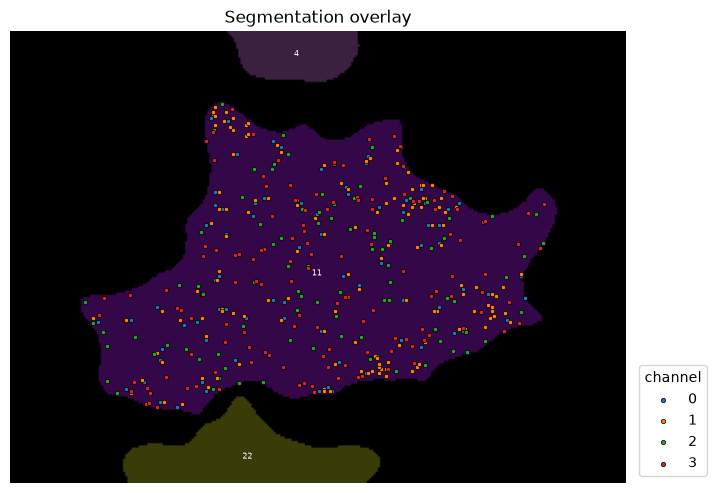

(<Figure size 800x587.05 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

In [10]:
spots_A = df_spots.loc[
    (df_spots["channel"] == 0) & (df_spots["label_cell"] == cell_id)
][["y", "x"]].to_numpy()
spots_B = df_spots.loc[
    (df_spots["channel"] == 1) & (df_spots["label_cell"] == cell_id)
][["y", "x"]].to_numpy()

n_A, n_B = spots_A.shape[0], spots_B.shape[0]

rnd_A = random_points_in_mask(mask, cell_label=cell_id, n=n_A)
rnd_B = random_points_in_mask(mask, cell_label=cell_id, n=n_B)

overlay_labels(
    label_mask=mask, coordinates=[spots_A, spots_B, rnd_A, rnd_B], focus_object=cell_id
)

In [11]:
nn_AtoB = KDTree(spots_B).query(spots_A, k=1)[0].mean()
nn_BtoA = KDTree(spots_A).query(spots_B, k=1)[0].mean()

nn_ArndB = KDTree(rnd_B).query(spots_A, k=1)[0].mean()
nn_BrndA = KDTree(rnd_A).query(spots_B, k=1)[0].mean()

print("Mean NN dist. A->B:", nn_AtoB)
print("Mean NN dist. B->A:", nn_BtoA)
print("Mean NN dist. A->random(B):", nn_ArndB)
print("Mean NN dist. B->random(A):", nn_BrndA)

Mean NN dist. A->B: 1.9655708446943665
Mean NN dist. B->A: 3.207888882211614
Mean NN dist. A->random(B): 6.533843237525505
Mean NN dist. B->random(A): 7.5547308542865945


In [12]:
ce_AB = nn_AtoB / nn_ArndB
ce_BA = nn_BtoA / nn_BrndA

print("Clark-Evans index A->B:", ce_AB)
print("Clark-Evans index B->A:", ce_BA)

Clark-Evans index A->B: 0.30082920162601984
Clark-Evans index B->A: 0.4246198764832821


In [13]:
n_repeats = 100

sims_AtoB, sims_BtoA = [], []
for _ in range(n_repeats):
    rnd_A = random_points_in_mask(mask, cell_label=cell_id, n=n_A)
    rnd_B = random_points_in_mask(mask, cell_label=cell_id, n=n_B)
    sims_AtoB.append(KDTree(rnd_B).query(spots_A, k=1)[0].mean())
    sims_BtoA.append(KDTree(rnd_A).query(spots_B, k=1)[0].mean())

sims_AtoB = np.array(sims_AtoB)
sims_BtoA = np.array(sims_BtoA)

print("nn_AtoB", nn_AtoB)
print("nn_BtoA", nn_BtoA)
print("nn_random_AtoB", sims_AtoB.mean())
print("nn_random_BtoA", sims_BtoA.mean())
print("ce_AtoB", nn_AtoB / sims_AtoB.mean())
print("ce_BtoA", nn_BtoA / sims_BtoA.mean())
print("pval_AtoB", (sims_AtoB <= nn_AtoB).mean())
print("pval_BtoA", (sims_BtoA <= nn_BtoA).mean())

nn_AtoB 1.9655708446943665
nn_BtoA 3.207888882211614
nn_random_AtoB 5.96855103488785
nn_random_BtoA 7.628145474213061
ce_AtoB 0.32932127633743186
ce_BtoA 0.4205332597622685
pval_AtoB 0.0
pval_BtoA 0.0


In [14]:
# or use:
# from bobiac_tools import cross_nn


def cross_nn(
    spots_A: np.ndarray,
    spots_B: np.ndarray,
    mask: np.ndarray,
    cell_id: int,
    n_repeats: int,
) -> dict[str, float]:
    """
    Test whether two sets of spots are more co-localized than expected under
    CSR using cross nearest-neighbor distances.

    For each point in A, the nearest neighbor in B is found (and vice versa).
    For the A→B direction, the null distribution holds A at its observed
    positions and randomizes only B (and vice versa for B→A) — this tests
    whether the *real* configuration of one set is closer to the other than
    a same-sized random configuration would be, controlling for the
    reference set's density without discarding the query set's real spatial
    structure.

    The two directions (A→B and B→A) can differ when the sets have different
    sizes: a small set is always close to a large one even by chance.

    Parameters
    ----------
    spots_A, spots_B : (n, 2) numpy arrays
        Spot coordinates in (row, col) / (y, x) order.
    mask : 2D numpy array
        Label mask where each cell is identified by a unique integer ID.
    cell_id : int
        ID of the cell in mask that both spot sets belong to.
    n_repeats : int
        Number of CSR simulations to run.

    Returns
    -------
    dict with keys:
        nn_AtoB, nn_BtoA : float
            Observed mean cross-NN distance in each direction.
        nn_random_AtoB, nn_random_BtoA : float
            Mean of simulated cross-NN distances under CSR.
        ce_AtoB, ce_BtoA : float
            Cross Clark-Evans index (observed / random). < 1 indicates
            co-localization, > 1 indicates avoidance.
        pval_AtoB, pval_BtoA : float
            Fraction of simulations with cross-NN <= observed.
            Small values indicate significant co-localization.
    """
    n_A, n_B = spots_A.shape[0], spots_B.shape[0]

    # observed cross-NN distances
    nn_AtoB = KDTree(spots_B).query(spots_A, k=1)[0].mean()
    nn_BtoA = KDTree(spots_A).query(spots_B, k=1)[0].mean()

    sims_AtoB, sims_BtoA = [], []
    for _ in range(n_repeats):
        rnd_A = random_points_in_mask(mask, cell_label=cell_id, n=n_A)
        rnd_B = random_points_in_mask(mask, cell_label=cell_id, n=n_B)
        sims_AtoB.append(KDTree(rnd_B).query(spots_A, k=1)[0].mean())
        sims_BtoA.append(KDTree(rnd_A).query(spots_B, k=1)[0].mean())

    sims_AtoB = np.array(sims_AtoB)
    sims_BtoA = np.array(sims_BtoA)

    return {
        "nn_AtoB": nn_AtoB,
        "nn_BtoA": nn_BtoA,
        "nn_random_AtoB": sims_AtoB.mean(),
        "nn_random_BtoA": sims_BtoA.mean(),
        "ce_AtoB": nn_AtoB / sims_AtoB.mean(),
        "ce_BtoA": nn_BtoA / sims_BtoA.mean(),
        "pval_AtoB": (sims_AtoB <= nn_AtoB).mean(),
        "pval_BtoA": (sims_BtoA <= nn_BtoA).mean(),
    }

In [15]:
spots_A = df_spots.loc[
    (df_spots["channel"] == 0) & (df_spots["label_cell"] == cell_id)
][["y", "x"]].to_numpy()
spots_B = df_spots.loc[
    (df_spots["channel"] == 1) & (df_spots["label_cell"] == cell_id)
][["y", "x"]].to_numpy()
print(
    cross_nn(spots_A=spots_A, spots_B=spots_B, mask=mask, cell_id=cell_id, n_repeats=10)
)

{'nn_AtoB': np.float64(1.9655708446943665), 'nn_BtoA': np.float64(3.207888882211614), 'nn_random_AtoB': np.float64(5.969043240707505), 'nn_random_BtoA': np.float64(7.704319012241365), 'ce_AtoB': np.float64(0.32929412058696855), 'ce_BtoA': np.float64(0.41637539633478454), 'pval_AtoB': np.float64(0.0), 'pval_BtoA': np.float64(0.0)}


In [16]:
n_repeats = 10

results = []
for cell_id in df_cell["label"].unique():
    spots_A = df_spots.loc[
        (df_spots["channel"] == 0) & (df_spots["label_cell"] == cell_id)
    ][["y", "x"]].to_numpy()
    spots_B = df_spots.loc[
        (df_spots["channel"] == 1) & (df_spots["label_cell"] == cell_id)
    ][["y", "x"]].to_numpy()

    # calculate the NN distance, Clark-Evans index and p-value for that cell
    results.append(
        cross_nn(
            spots_A=spots_A,
            spots_B=spots_B,
            mask=mask,
            cell_id=cell_id,
            n_repeats=n_repeats,
        )
    )

df_cell = pd.concat([df_cell, pd.DataFrame(results)], axis=1)
df_cell

,area,label,count,nn_AtoB,nn_BtoA,nn_random_AtoB,nn_random_BtoA,ce_AtoB,ce_BtoA,pval_AtoB,pval_BtoA
0,4669.0,2,23,1.742602,5.578599,4.691437,8.431806,0.371443,0.661614,0.0,0.0
1,7866.0,3,39,1.776632,3.954749,4.759385,7.483377,0.373290,0.528471,0.0,0.0
2,6945.0,4,34,1.764162,5.842747,4.767084,7.394651,0.370072,0.790131,0.0,0.0
3,9735.0,5,48,1.777044,4.682295,5.495804,7.076684,0.323346,0.661651,0.0,0.0
4,7749.0,6,38,1.730490,6.242496,5.106933,8.331586,0.338851,0.749257,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
72,9504.0,80,47,1.715710,3.593778,5.206823,7.209218,0.329512,0.498498,0.0,0.0
73,2878.0,81,14,1.504764,7.685147,3.496796,7.448302,0.430326,1.031798,0.0,0.5
74,1881.0,83,9,2.093022,10.883218,3.069716,8.071630,0.681829,1.348330,0.0,1.0
75,4198.0,85,20,1.648309,6.056318,4.342187,8.007327,0.379603,0.756347,0.0,0.0


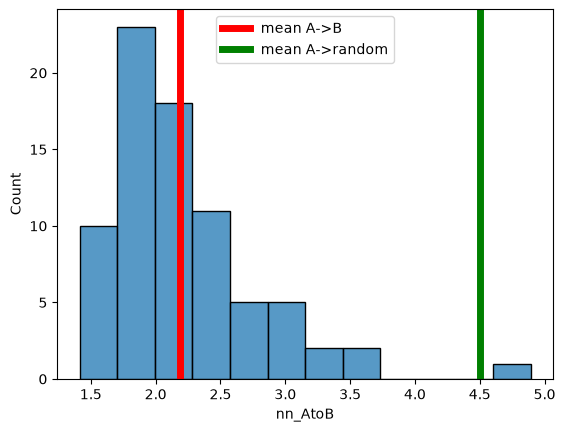

In [17]:
sns.histplot(
    df_cell,
    x="nn_AtoB",
)
plt.axvline(df_cell["nn_AtoB"].mean(), c="red", lw=5, label="mean A->B")
plt.axvline(df_cell["nn_random_AtoB"].mean(), c="green", lw=5, label="mean A->random")
plt.legend()

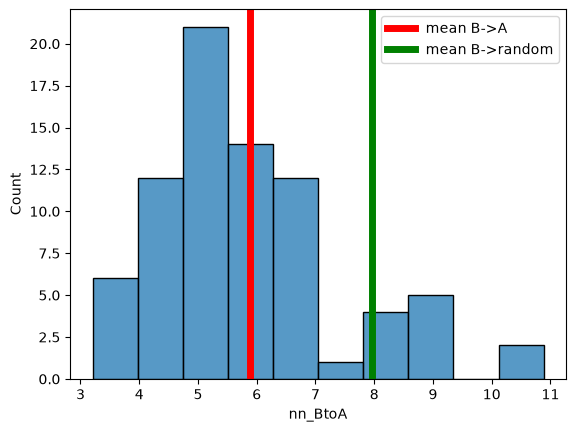

In [18]:
sns.histplot(
    df_cell,
    x="nn_BtoA",
)
plt.axvline(df_cell["nn_BtoA"].mean(), c="red", lw=5, label="mean B->A")
plt.axvline(df_cell["nn_random_BtoA"].mean(), c="green", lw=5, label="mean B->random")
plt.legend()

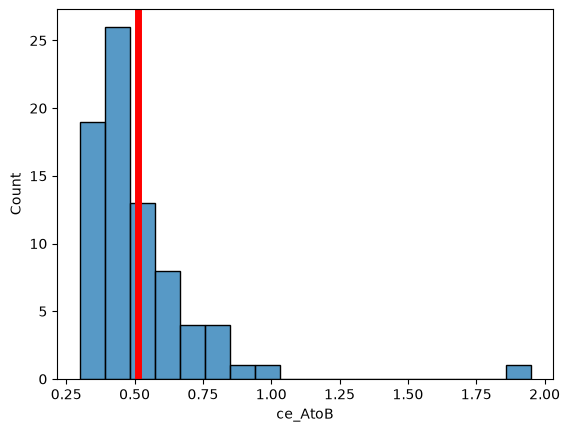

In [19]:
sns.histplot(
    df_cell,
    x="ce_AtoB",
)
plt.axvline(df_cell["ce_AtoB"].mean(), c="red", lw=5)

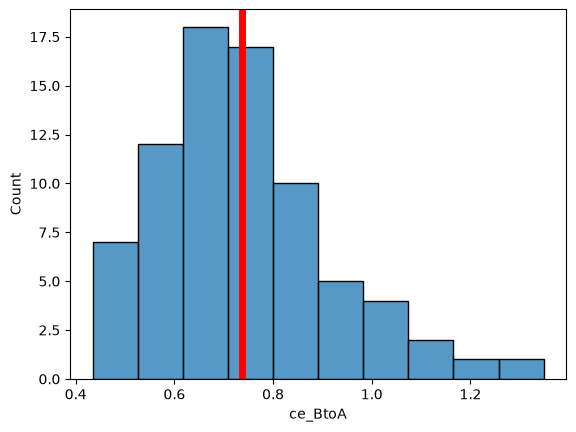

In [20]:
sns.histplot(
    df_cell,
    x="ce_BtoA",
)
plt.axvline(df_cell["ce_BtoA"].mean(), c="red", lw=5)